# BÀI THỰC HÀNH 5: KIẾN TRÚC TRANSFORMER ENCODER

In [6]:
import json
import os
import math
from collections import Counter

import re
import unicodedata
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


# Bài 1:
 Xây dựng mô hình Transformer Encoder gồm 3 lớp theo mô tả trong nghiên cứu [Attention is all you need](https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf). Huấn luyện mô hình này cho bài toán phân loại domain câu bình luận trên bộ dữ liệu [UIT-ViOCD](https://drive.google.com/drive/folders/1Lu9axyLkw7dMx80uLRgvCnZsmNzhJWAa?usp=sharing).

### 1. Tải và kiểm tra dữ liệu UIT-ViOCD


In [2]:
!gdown --folder https://drive.google.com/drive/folders/1Lu9axyLkw7dMx80uLRgvCnZsmNzhJWAa

Retrieving folder contents
Processing file 1HyTr0D1vii0NWZGJBo8L98npE7AtKrrg dev.json
Processing file 1b1gb-p9SZ3-qrxT1dO1-z9UyHvQ-__R4 test.json
Processing file 1afbZp0WcBG43UJA_By0FcttY8clG7s2s train.json
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1HyTr0D1vii0NWZGJBo8L98npE7AtKrrg
To: /content/UIT-ViOCD/dev.json
100% 167k/167k [00:00<00:00, 85.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1b1gb-p9SZ3-qrxT1dO1-z9UyHvQ-__R4
To: /content/UIT-ViOCD/test.json
100% 166k/166k [00:00<00:00, 122MB/s]
Downloading...
From: https://drive.google.com/uc?id=1afbZp0WcBG43UJA_By0FcttY8clG7s2s
To: /content/UIT-ViOCD/train.json
100% 1.32M/1.32M [00:00<00:00, 110MB/s]
Download completed


In [3]:
data_dir_viocd = "./UIT-ViOCD"

def load_json_dict(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

# Load dữ liệu
train_raw_viocd = load_json_dict(os.path.join(data_dir_viocd, "train.json"))
dev_raw_viocd = load_json_dict(os.path.join(data_dir_viocd, "dev.json"))
test_raw_viocd = load_json_dict(os.path.join(data_dir_viocd, "test.json"))

print(f"Train samples: {len(train_raw_viocd)}")
print(f"Dev samples: {len(dev_raw_viocd)}")
print(f"Test samples: {len(test_raw_viocd)}")

# Xem mẫu dữ liệu
if train_raw_viocd:
    first_key = list(train_raw_viocd.keys())[0]
    print(f"\nSample data:")
    print(train_raw_viocd[first_key])


Train samples: 4387
Dev samples: 548
Test samples: 549

Sample data:
{'review': 'gói hàng cẩn thận . chơi pubg với liên quân mượt với giá như này thì quá tốt', 'label': 'non-complaint', 'domain': 'mobile'}


### 2. Tiền xử lý dữ liệu và xây dựng vocabulary


In [7]:
# Regex emoji tương đối đầy đủ (Unicode ranges phổ biến)
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FAFF"
    "\u2600-\u26FF"          # misc symbols
    "\u2700-\u27BF"
    "]+",
    flags=re.UNICODE
)

def preprocess_text_simple(text):
    """Tiền xử lý tối thiểu cho Transformer (đúng tinh thần paper gốc)"""
    if not text:
        return ""

    # Unicode normalization (NFC)
    text = unicodedata.normalize("NFC", text)

    # Xóa emoji
    text = EMOJI_PATTERN.sub("", text)

    # Chuẩn hóa khoảng trắng
    text = " ".join(text.strip().split())

    # Lowercase
    return text.lower()

# Lấy tất cả reviews và domains từ train data
all_reviews = []
all_domains = []

for key, item in train_raw_viocd.items():
    review = item.get("review", "")
    domain = item.get("domain", "")
    if review and domain:
        all_reviews.append(preprocess_text_simple(review))
        all_domains.append(domain)

# Xây dựng vocabulary từ train data
all_tokens = []
for review in all_reviews:
    tokens = review.split()
    all_tokens.extend(tokens)

vocab_counter = Counter(all_tokens)
vocab = ['<pad>', '<unk>'] + [tok for tok, count in vocab_counter.items() if count >= 1]
word2idx = {word: idx for idx, word in enumerate(vocab)}
vocab_size = len(vocab)

# Xây dựng domain labels
domain_set = sorted(list(set(all_domains)))
domain2idx = {domain: idx for idx, domain in enumerate(domain_set)}
num_domains = len(domain_set)

print(f"Vocabulary size: {vocab_size}")
print(f"Number of domains: {num_domains}")
print(f"Domains: {domain_set}")
print(f"\nSample vocab (first 20): {vocab[:20]}")


Vocabulary size: 4511
Number of domains: 4
Domains: ['app', 'cosmetic', 'fashion', 'mobile']

Sample vocab (first 20): ['<pad>', '<unk>', 'gói', 'hàng', 'cẩn', 'thận', '.', 'chơi', 'pubg', 'với', 'liên', 'quân', 'mượt', 'giá', 'như', 'này', 'thì', 'quá', 'tốt', 'mình']


### 3. Encode dữ liệu


In [9]:
def encode_sentence(sentence, word2idx, max_len):
    """Encode sentence thành indices"""
    tokens = sentence.split()
    idxs = [word2idx.get(token, word2idx['<unk>']) for token in tokens]
    if len(idxs) < max_len:
        idxs += [word2idx['<pad>']] * (max_len - len(idxs))
    else:
        idxs = idxs[:max_len]
    return idxs

# Xác định max_len dựa trên phân tích độ dài câu
sentence_lengths = [len(review.split()) for review in all_reviews]
max_len_viocd = int(np.percentile(sentence_lengths, 95))  # 95th percentile
print(f"Max sequence length (95th percentile): {max_len_viocd}")

def process_viocd_data(data_dict, word2idx, domain2idx, max_len):
    """Process UIT-ViOCD data"""
    encoded = []
    labels = []

    for key, item in data_dict.items():
        review = item.get("review", "")
        domain = item.get("domain", "")
        if review and domain:
            processed_review = preprocess_text_simple(review)
            encoded_review = encode_sentence(processed_review, word2idx, max_len)
            encoded.append(encoded_review)
            labels.append(domain2idx[domain])

    return encoded, labels

# Process tất cả các tập
X_train_viocd, y_train_viocd = process_viocd_data(train_raw_viocd, word2idx, domain2idx, max_len_viocd)
X_dev_viocd, y_dev_viocd = process_viocd_data(dev_raw_viocd, word2idx, domain2idx, max_len_viocd)
X_test_viocd, y_test_viocd = process_viocd_data(test_raw_viocd, word2idx, domain2idx, max_len_viocd)

print(f"Train: {len(X_train_viocd)} samples")
print(f"Dev: {len(X_dev_viocd)} samples")
print(f"Test: {len(X_test_viocd)} samples")


Max sequence length (95th percentile): 84
Train: 4387 samples
Dev: 548 samples
Test: 549 samples


### 4. Xây dựng Transformer Encoder Architecture


In [11]:
class PositionalEncoding(nn.Module):
    """Positional Encoding theo paper 'Attention is all you need'"""
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Tạo ma trận positional encoding
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)  # (max_len, 1, d_model)

        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x: Tensor shape (seq_len, batch_size, d_model)
        """
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)


class MultiHeadAttention(nn.Module):
    """Multi-Head Attention theo paper 'Attention is all you need'"""
    def __init__(self, d_model, num_heads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """Scaled Dot-Product Attention"""
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        output = torch.matmul(attention_weights, V)

        return output, attention_weights

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        # Linear transformations và split into heads
        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Apply attention
        attn_output, attention_weights = self.scaled_dot_product_attention(Q, K, V, mask)

        # Concatenate heads
        attn_output = attn_output.transpose(1, 2).contiguous().view(
            batch_size, -1, self.d_model
        )

        # Final linear layer
        output = self.W_o(attn_output)

        return output


class FeedForward(nn.Module):
    """Position-wise Feed-Forward Networks"""
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(FeedForward, self).__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))


class TransformerEncoderLayer(nn.Module):
    """Một lớp Transformer Encoder"""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(TransformerEncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Self-attention với residual connection
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout1(attn_output))

        # Feed-forward với residual connection
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout2(ff_output))

        return x


class TransformerEncoderClassifier(nn.Module):
    """Transformer Encoder cho bài toán phân loại domain"""
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff,
                 max_seq_len, num_classes, pad_idx, dropout=0.1):
        super(TransformerEncoderClassifier, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(d_model, max_seq_len, dropout)

        # Stack các encoder layers
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x, mask=None):
        # x: (batch_size, seq_len)
        seq_len = x.size(1)

        # Embedding
        x = self.embedding(x) * math.sqrt(self.d_model)  # (batch_size, seq_len, d_model)

        # Transpose để phù hợp với positional encoding: (seq_len, batch_size, d_model)
        x = x.transpose(0, 1)
        x = self.pos_encoding(x)
        x = x.transpose(0, 1)  # (batch_size, seq_len, d_model)

        x = self.dropout(x)

        # Pass qua các encoder layers
        for encoder_layer in self.encoder_layers:
            x = encoder_layer(x, mask)

        if mask is not None:
            # Mask out padding tokens khi tính mean
            mask_expanded = mask.unsqueeze(-1).float()
            x = x * mask_expanded
            pooled = x.sum(dim=1) / mask_expanded.sum(dim=1)
        else:
            pooled = x.mean(dim=1)

        # Classification
        output = self.fc(pooled)

        return output


In [12]:
class DomainDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset_viocd = DomainDataset(X_train_viocd, y_train_viocd)
dev_dataset_viocd = DomainDataset(X_dev_viocd, y_dev_viocd)
test_dataset_viocd = DomainDataset(X_test_viocd, y_test_viocd)

batch_size_viocd = 32
train_loader_viocd = DataLoader(train_dataset_viocd, batch_size=batch_size_viocd, shuffle=True)
dev_loader_viocd = DataLoader(dev_dataset_viocd, batch_size=batch_size_viocd, shuffle=False)
test_loader_viocd = DataLoader(test_dataset_viocd, batch_size=batch_size_viocd, shuffle=False)

print(f"Train batches: {len(train_loader_viocd)}")
print(f"Dev batches: {len(dev_loader_viocd)}")
print(f"Test batches: {len(test_loader_viocd)}")


Train batches: 138
Dev batches: 18
Test batches: 18


### 6. Khởi tạo mô hình và huấn luyện


In [16]:
# Hyperparameters
d_model = 256
num_heads = 8
num_layers = 3
d_ff = 1024
dropout = 0.1
pad_idx = word2idx['<pad>']

# Khởi tạo mô hình
model_viocd = TransformerEncoderClassifier(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers,
    d_ff=d_ff,
    max_seq_len=max_len_viocd,
    num_classes=num_domains,
    pad_idx=pad_idx,
    dropout=dropout
).to(device)

criterion_viocd = nn.CrossEntropyLoss()
optimizer_viocd = optim.Adam(model_viocd.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

print(f"Model parameters: {sum(p.numel() for p in model_viocd.parameters()):,}")
print(f"Model architecture:")
print(model_viocd)


Model parameters: 3,525,124
Model architecture:
TransformerEncoderClassifier(
  (embedding): Embedding(4511, 256, padding_idx=0)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder_layers): ModuleList(
    (0-2): 3 x TransformerEncoderLayer(
      (self_attn): MultiHeadAttention(
        (W_q): Linear(in_features=256, out_features=256, bias=True)
        (W_k): Linear(in_features=256, out_features=256, bias=True)
        (W_v): Linear(in_features=256, out_features=256, bias=True)
        (W_o): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForward(
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=

In [17]:
def evaluate_classification(model, data_loader, device):
    """Đánh giá mô hình phân loại"""
    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(list(preds))
            all_true.extend(list(yb.numpy()))

    f1_macro = f1_score(all_true, all_preds, average="macro")
    f1_micro = f1_score(all_true, all_preds, average="micro")
    return f1_macro, f1_micro


def train_classification_model(model, train_loader, dev_loader, criterion, optimizer,
                               device, num_epochs, patience=10, delta=1e-5,
                               save_path="best_model_viocd.pt"):
    """Huấn luyện mô hình với early stopping"""
    train_losses = []
    val_f1s = []
    best_f1 = None
    patience_counter = 0

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item() * xb.size(0)

        avg_loss = total_loss / len(train_loader.dataset)
        train_losses.append(avg_loss)

        # Evaluation trên dev set
        f1_macro, f1_micro = evaluate_classification(model, dev_loader, device)
        val_f1s.append(f1_macro)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_loss:.4f}, "
              f"Val F1 (macro): {f1_macro:.4f}, Val F1 (micro): {f1_micro:.4f}")

        # Early stopping
        if best_f1 is None or f1_macro > best_f1 + delta:
            best_f1 = f1_macro
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"✓ Best model saved at epoch {epoch+1} with F1 {best_f1:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # Load best model
    model.load_state_dict(torch.load(save_path))
    return model, train_losses, val_f1s


# Huấn luyện mô hình
num_epochs_viocd = 50
model_viocd, train_losses_viocd, val_f1s_viocd = train_classification_model(
    model=model_viocd,
    train_loader=train_loader_viocd,
    dev_loader=dev_loader_viocd,
    criterion=criterion_viocd,
    optimizer=optimizer_viocd,
    device=device,
    num_epochs=num_epochs_viocd,
    save_path="best_model_viocd.pt"
)

# Đánh giá trên test set
f1_macro_test, f1_micro_test = evaluate_classification(model_viocd, test_loader_viocd, device)
print(f"\n{'='*60}")
print(f"Test Results:")
print(f"F1 Score (macro): {f1_macro_test:.4f}")
print(f"F1 Score (micro): {f1_micro_test:.4f}")
print(f"{'='*60}")


Epoch 1/50, Train Loss: 0.7100, Val F1 (macro): 0.7572, Val F1 (micro): 0.8248
✓ Best model saved at epoch 1 with F1 0.7572
Epoch 2/50, Train Loss: 0.4495, Val F1 (macro): 0.7870, Val F1 (micro): 0.8339
✓ Best model saved at epoch 2 with F1 0.7870
Epoch 3/50, Train Loss: 0.3671, Val F1 (macro): 0.8157, Val F1 (micro): 0.8668
✓ Best model saved at epoch 3 with F1 0.8157
Epoch 4/50, Train Loss: 0.3324, Val F1 (macro): 0.8105, Val F1 (micro): 0.8650
Epoch 5/50, Train Loss: 0.2944, Val F1 (macro): 0.8367, Val F1 (micro): 0.8759
✓ Best model saved at epoch 5 with F1 0.8367
Epoch 6/50, Train Loss: 0.2764, Val F1 (macro): 0.8383, Val F1 (micro): 0.8796
✓ Best model saved at epoch 6 with F1 0.8383
Epoch 7/50, Train Loss: 0.2508, Val F1 (macro): 0.8421, Val F1 (micro): 0.8850
✓ Best model saved at epoch 7 with F1 0.8421
Epoch 8/50, Train Loss: 0.2457, Val F1 (macro): 0.8427, Val F1 (micro): 0.8905
✓ Best model saved at epoch 8 with F1 0.8427
Epoch 9/50, Train Loss: 0.2266, Val F1 (macro): 0.829

### 7. Visualization kết quả


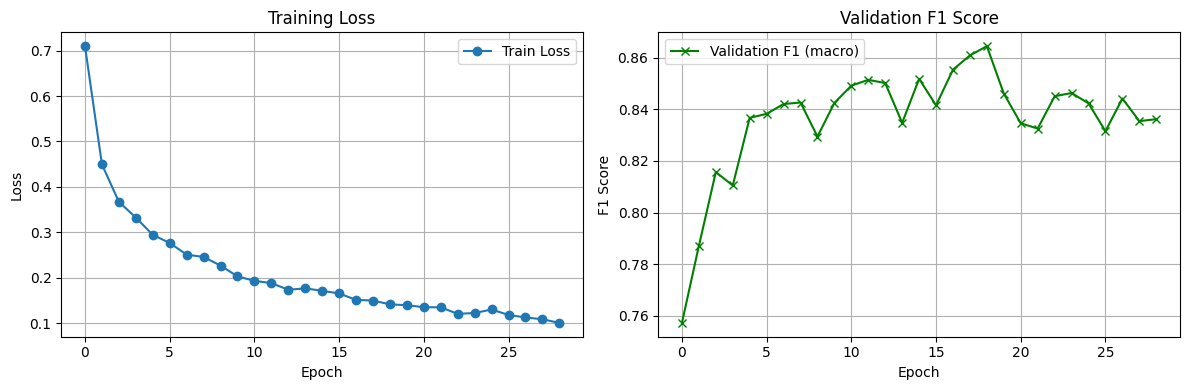

In [18]:
# Vẽ biểu đồ training progress
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses_viocd, label='Train Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_f1s_viocd, label='Validation F1 (macro)', marker='x', color='green')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('Validation F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Bài 2:
Xây dựng mô hình Transformer Encoder gồm 3 lớp theo mô tả trong nghiên cứu [Attention is all you need](https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf). Huấn luyện mô hình này cho bài toán gán nhãn chuỗi trên bộ dữ liệu [PhoNERT](https://github.com/VinAIResearch/PhoNER_COVID19).

### 1. Tải và kiểm tra dữ liệu PhoNERT


In [19]:
!wget https://github.com/VinAIResearch/PhoNER_COVID19/archive/refs/heads/master.zip
!unzip master.zip

--2026-01-01 10:21:09--  https://github.com/VinAIResearch/PhoNER_COVID19/archive/refs/heads/master.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/VinAIResearch/PhoNER_COVID19/zip/main [following]
--2026-01-01 10:21:10--  https://codeload.github.com/VinAIResearch/PhoNER_COVID19/zip/main
Resolving codeload.github.com (codeload.github.com)... 20.205.243.165
Connecting to codeload.github.com (codeload.github.com)|20.205.243.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [   <=>              ]   3.60M  7.15MB/s    in 0.5s    

2026-01-01 10:21:10 (7.15 MB/s) - ‘master.zip’ saved [3777533]

Archive:  master.zip
9af190aa76adcfad0a2d14fab9bcab2b252c9c2e
   creating: PhoNER_COVID19-main/
  inflating: PhoNER_COVID19-main/

In [20]:
data_dir_phoner = "./PhoNER_COVID19-main/data/word"

def load_jsonl(file_path):
    """Load JSONL format - mỗi dòng là một JSON object"""
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    item = json.loads(line)
                    data.append(item)
                except json.JSONDecodeError as e:
                    print(f"Error parsing line: {line[:50]}...")
                    continue
    return data

# Load dữ liệu
train_data_phoner = load_jsonl(os.path.join(data_dir_phoner, "train_word.json"))
dev_data_phoner = load_jsonl(os.path.join(data_dir_phoner, "dev_word.json"))
test_data_phoner = load_jsonl(os.path.join(data_dir_phoner, "test_word.json"))

print(f"Train sentences: {len(train_data_phoner)}")
print(f"Dev sentences: {len(dev_data_phoner)}")
print(f"Test sentences: {len(test_data_phoner)}")

# Xem mẫu dữ liệu
if train_data_phoner:
    print(f"\nSample data:")
    sample = train_data_phoner[0]
    print(f"Words: {sample.get('words', [])[:10]}")
    print(f"Tags: {sample.get('tags', [])[:10]}")


Train sentences: 5027
Dev sentences: 2000
Test sentences: 3000

Sample data:
Words: ['Đồng_thời', ',', 'bệnh_viện', 'tiếp_tục', 'thực_hiện', 'các', 'biện_pháp', 'phòng_chống', 'dịch_bệnh', 'COVID']
Tags: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


### 2. Xây dựng vocabulary và labels cho NER


In [21]:
# Xây dựng vocabulary từ train data
all_tokens_phoner = []
for item in train_data_phoner:
    tokens = item.get('words', item.get('tokens', []))
    all_tokens_phoner.extend(tokens)

vocab_counter_phoner = Counter(all_tokens_phoner)
vocab_phoner = ['<pad>', '<unk>'] + [tok for tok, count in vocab_counter_phoner.items() if count >= 1]
word2idx_phoner = {word: idx for idx, word in enumerate(vocab_phoner)}
vocab_size_phoner = len(vocab_phoner)

# Xây dựng label vocabulary
all_labels_phoner = []
for item in train_data_phoner:
    labels = item.get('tags', item.get('ner_tags', []))
    all_labels_phoner.extend(labels)

label_set_phoner = sorted(list(set(all_labels_phoner)))
label_vocab_phoner = ['<pad>'] + label_set_phoner
label2idx_phoner = {label: idx for idx, label in enumerate(label_vocab_phoner)}
idx2label_phoner = {idx: label for label, idx in label2idx_phoner.items()}
num_labels_phoner = len(label2idx_phoner)

pad_token_idx_phoner = word2idx_phoner['<pad>']
pad_label_idx_phoner = label2idx_phoner['<pad>']

print(f"Vocabulary size: {vocab_size_phoner}")
print(f"Number of labels: {num_labels_phoner}")
print(f"Labels: {label_vocab_phoner[:15]}...")

# Phân tích độ dài câu
sentence_lengths_phoner = [len(item.get('words', [])) for item in train_data_phoner]
max_len_phoner = int(np.percentile(sentence_lengths_phoner, 95))
print(f"\nSentence length stats:")
print(f"Min: {np.min(sentence_lengths_phoner)}, Max: {np.max(sentence_lengths_phoner)}, "
      f"Mean: {np.mean(sentence_lengths_phoner):.2f}")
print(f"Using max_len: {max_len_phoner}")


Vocabulary size: 5243
Number of labels: 21
Labels: ['<pad>', 'B-AGE', 'B-DATE', 'B-GENDER', 'B-JOB', 'B-LOCATION', 'B-NAME', 'B-ORGANIZATION', 'B-PATIENT_ID', 'B-SYMPTOM_AND_DISEASE', 'B-TRANSPORTATION', 'I-AGE', 'I-DATE', 'I-JOB', 'I-LOCATION']...

Sentence length stats:
Min: 6, Max: 161, Mean: 26.36
Using max_len: 50


### 3. Encode dữ liệu NER


In [22]:
def encode_ner_sentence(tokens, labels, word2idx, label2idx, max_len):
    """Encode tokens và labels thành indices"""
    if not tokens or not labels:
        return [word2idx['<pad>']] * max_len, [label2idx['<pad>']] * max_len

    # Đảm bảo tokens và labels cùng độ dài
    min_len = min(len(tokens), len(labels))
    tokens = tokens[:min_len]
    labels = labels[:min_len]

    token_ids = [word2idx.get(token, word2idx['<unk>']) for token in tokens]
    label_ids = [label2idx.get(label, label2idx['<pad>']) for label in labels]

    # Pad hoặc truncate
    if len(token_ids) < max_len:
        pad_len = max_len - len(token_ids)
        token_ids += [word2idx['<pad>']] * pad_len
        label_ids += [label2idx['<pad>']] * pad_len
    else:
        token_ids = token_ids[:max_len]
        label_ids = label_ids[:max_len]

    return token_ids, label_ids


def process_ner_data(data_raw, word2idx, label2idx, max_len):
    """Process NER data"""
    encoded = []
    labels_encoded = []

    for item in data_raw:
        tokens = item.get('words', item.get('tokens', []))
        labels = item.get('tags', item.get('ner_tags', []))

        if not tokens or not labels:
            continue

        token_ids, label_ids = encode_ner_sentence(tokens, labels, word2idx, label2idx, max_len)
        encoded.append(token_ids)
        labels_encoded.append(label_ids)

    return encoded, labels_encoded

# Process tất cả các tập
X_train_phoner, y_train_phoner = process_ner_data(
    train_data_phoner, word2idx_phoner, label2idx_phoner, max_len_phoner
)
X_dev_phoner, y_dev_phoner = process_ner_data(
    dev_data_phoner, word2idx_phoner, label2idx_phoner, max_len_phoner
)
X_test_phoner, y_test_phoner = process_ner_data(
    test_data_phoner, word2idx_phoner, label2idx_phoner, max_len_phoner
)

print(f"Train: {len(X_train_phoner)} samples")
print(f"Dev: {len(X_dev_phoner)} samples")
print(f"Test: {len(X_test_phoner)} samples")


Train: 5027 samples
Dev: 2000 samples
Test: 3000 samples


### 4. Xây dựng Transformer Encoder cho NER


In [23]:
class TransformerEncoderNER(nn.Module):
    """Transformer Encoder cho bài toán gán nhãn chuỗi (NER)"""
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff,
                 max_seq_len, num_labels, pad_idx, dropout=0.1):
        super(TransformerEncoderNER, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(d_model, max_seq_len, dropout)

        # Stack các encoder layers
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        # Output layer cho mỗi token
        self.fc = nn.Linear(d_model, num_labels)

    def forward(self, x, mask=None):
        # x: (batch_size, seq_len)
        seq_len = x.size(1)

        # Embedding
        x = self.embedding(x) * math.sqrt(self.d_model)  # (batch_size, seq_len, d_model)

        # Positional encoding
        x = x.transpose(0, 1)  # (seq_len, batch_size, d_model)
        x = self.pos_encoding(x)
        x = x.transpose(0, 1)  # (batch_size, seq_len, d_model)

        x = self.dropout(x)

        # Pass qua các encoder layers
        for encoder_layer in self.encoder_layers:
            x = encoder_layer(x, mask)

        # Output logits cho mỗi token
        logits = self.fc(x)  # (batch_size, seq_len, num_labels)

        return logits


### 5. Tạo Dataset và DataLoader cho NER


In [24]:
class NERDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Tạo datasets
train_dataset_phoner = NERDataset(X_train_phoner, y_train_phoner)
dev_dataset_phoner = NERDataset(X_dev_phoner, y_dev_phoner)
test_dataset_phoner = NERDataset(X_test_phoner, y_test_phoner)

# Tạo dataloaders
batch_size_phoner = 32
train_loader_phoner = DataLoader(train_dataset_phoner, batch_size=batch_size_phoner, shuffle=True)
dev_loader_phoner = DataLoader(dev_dataset_phoner, batch_size=batch_size_phoner, shuffle=False)
test_loader_phoner = DataLoader(test_dataset_phoner, batch_size=batch_size_phoner, shuffle=False)

print(f"Train batches: {len(train_loader_phoner)}")
print(f"Dev batches: {len(dev_loader_phoner)}")
print(f"Test batches: {len(test_loader_phoner)}")


Train batches: 158
Dev batches: 63
Test batches: 94


### 6. Khởi tạo mô hình và huấn luyện NER


In [25]:
# Hyperparameters
d_model_phoner = 256
num_heads_phoner = 8
num_layers_phoner = 3
d_ff_phoner = 1024
dropout_phoner = 0.1

# Khởi tạo mô hình
model_phoner = TransformerEncoderNER(
    vocab_size=vocab_size_phoner,
    d_model=d_model_phoner,
    num_heads=num_heads_phoner,
    num_layers=num_layers_phoner,
    d_ff=d_ff_phoner,
    max_seq_len=max_len_phoner,
    num_labels=num_labels_phoner,
    pad_idx=pad_token_idx_phoner,
    dropout=dropout_phoner
).to(device)

criterion_phoner = nn.CrossEntropyLoss(ignore_index=pad_label_idx_phoner)
optimizer_phoner = optim.Adam(model_phoner.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

print(f"Model parameters: {sum(p.numel() for p in model_phoner.parameters()):,}")
print(f"Model architecture:")
print(model_phoner)


Model parameters: 3,716,885
Model architecture:
TransformerEncoderNER(
  (embedding): Embedding(5243, 256, padding_idx=0)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder_layers): ModuleList(
    (0-2): 3 x TransformerEncoderLayer(
      (self_attn): MultiHeadAttention(
        (W_q): Linear(in_features=256, out_features=256, bias=True)
        (W_k): Linear(in_features=256, out_features=256, bias=True)
        (W_v): Linear(in_features=256, out_features=256, bias=True)
        (W_o): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForward(
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=1e-05, 

In [26]:
def evaluate_ner(model, data_loader, device, pad_label_idx):
    """Đánh giá mô hình NER (token-level F1)"""
    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            logits = model(xb)  # (B, T, C)
            preds = torch.argmax(logits, dim=-1)  # (B, T)

            # Flatten và bỏ qua padding tokens
            preds_flat = preds.view(-1).cpu().numpy()
            labels_flat = yb.view(-1).cpu().numpy()
            mask = labels_flat != pad_label_idx

            preds_flat = preds_flat[mask]
            labels_flat = labels_flat[mask]

            all_preds.extend(preds_flat.tolist())
            all_true.extend(labels_flat.tolist())

    f1_macro = f1_score(all_true, all_preds, average="macro", zero_division=0)
    f1_micro = f1_score(all_true, all_preds, average="micro", zero_division=0)
    return f1_macro, f1_micro


def train_ner_model(model, train_loader, dev_loader, criterion, optimizer,
                     device, num_epochs, pad_label_idx, patience=10, delta=1e-5,
                     save_path="best_model_phoner.pt"):
    """Huấn luyện mô hình NER với early stopping"""
    train_losses = []
    val_f1s = []
    best_f1 = None
    patience_counter = 0

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)  # (B, T, C)
            loss = criterion(logits.view(-1, logits.size(-1)), yb.view(-1))
            loss.backward()
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item() * xb.size(0)

        avg_loss = total_loss / len(train_loader.dataset)
        train_losses.append(avg_loss)

        # Evaluation trên dev set
        f1_macro, f1_micro = evaluate_ner(model, dev_loader, device, pad_label_idx)
        val_f1s.append(f1_macro)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_loss:.4f}, "
              f"Val F1 (macro): {f1_macro:.4f}, Val F1 (micro): {f1_micro:.4f}")

        # Early stopping
        if best_f1 is None or f1_macro > best_f1 + delta:
            best_f1 = f1_macro
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"✓ Best model saved at epoch {epoch+1} with F1 {best_f1:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # Load best model
    model.load_state_dict(torch.load(save_path))
    return model, train_losses, val_f1s


# Huấn luyện mô hình
num_epochs_phoner = 50
model_phoner, train_losses_phoner, val_f1s_phoner = train_ner_model(
    model=model_phoner,
    train_loader=train_loader_phoner,
    dev_loader=dev_loader_phoner,
    criterion=criterion_phoner,
    optimizer=optimizer_phoner,
    device=device,
    num_epochs=num_epochs_phoner,
    pad_label_idx=pad_label_idx_phoner,
    save_path="best_model_phoner.pt"
)

# Đánh giá trên test set
f1_macro_test_phoner, f1_micro_test_phoner = evaluate_ner(
    model_phoner, test_loader_phoner, device, pad_label_idx_phoner
)
print(f"\n{'='*60}")
print(f"Test Results (PhoNERT):")
print(f"F1 Score (macro): {f1_macro_test_phoner:.4f}")
print(f"F1 Score (micro): {f1_micro_test_phoner:.4f}")
print(f"{'='*60}")


Epoch 1/50, Train Loss: 0.8003, Val F1 (macro): 0.2976, Val F1 (micro): 0.8146
✓ Best model saved at epoch 1 with F1 0.2976
Epoch 2/50, Train Loss: 0.4933, Val F1 (macro): 0.3813, Val F1 (micro): 0.8459
✓ Best model saved at epoch 2 with F1 0.3813
Epoch 3/50, Train Loss: 0.4004, Val F1 (macro): 0.4485, Val F1 (micro): 0.8610
✓ Best model saved at epoch 3 with F1 0.4485
Epoch 4/50, Train Loss: 0.3466, Val F1 (macro): 0.4863, Val F1 (micro): 0.8695
✓ Best model saved at epoch 4 with F1 0.4863
Epoch 5/50, Train Loss: 0.3127, Val F1 (macro): 0.5091, Val F1 (micro): 0.8772
✓ Best model saved at epoch 5 with F1 0.5091
Epoch 6/50, Train Loss: 0.2882, Val F1 (macro): 0.5248, Val F1 (micro): 0.8813
✓ Best model saved at epoch 6 with F1 0.5248
Epoch 7/50, Train Loss: 0.2649, Val F1 (macro): 0.5446, Val F1 (micro): 0.8863
✓ Best model saved at epoch 7 with F1 0.5446
Epoch 8/50, Train Loss: 0.2474, Val F1 (macro): 0.5667, Val F1 (micro): 0.8900
✓ Best model saved at epoch 8 with F1 0.5667
Epoch 9/

### 7. Visualization kết quả NER


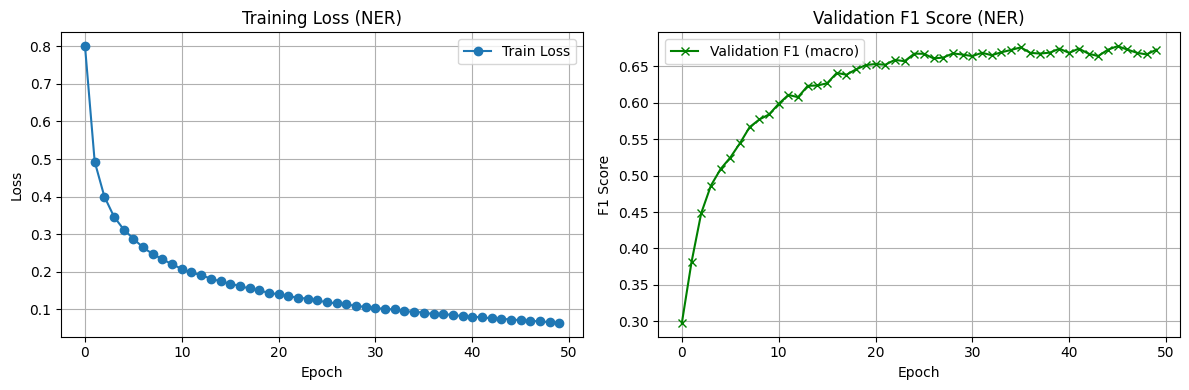

In [28]:
# Vẽ biểu đồ training progress
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses_phoner, label='Train Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss (NER)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_f1s_phoner, label='Validation F1 (macro)', marker='x', color='green')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('Validation F1 Score (NER)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
